In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

# Business Objective

The bank wants to understand customer characteristics and banking relationships associated with churn, identify vulnerable customer segments, and develop data-driven retention recommendations.

# Load the dataset


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Gaurav-Singh-K/Bank360-Customer-Financial-Performance-Analytics/main/Data/Bank_Churn.csv')

In [4]:
df.shape

(10000, 14)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,"101,348.88",1
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.86",1,0,1,"112,542.58",0
2,3,15619304,Onio,502,France,Female,42,8,"159,660.80",3,1,0,"113,931.57",1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,"93,826.63",0
4,5,15737888,Mitchell,850,Spain,Female,43,2,"125,510.82",1,1,1,"79,084.10",0


### Data Dictionary                                             

RowNumber: The sequential number assigned to each row in the dataset.

CustomerId: A unique identifier for each customer.

Surname: The surname of the customer.

CreditScore: The credit score of the customer.

Geography: The geographical location of the customer (e.g., country or region).

Gender: The gender of the customer.

Age: The age of the customer.

Tenure: The number of years the customer has been with the bank.

Balance: The account balance of the customer.

NumOfProducts: The number of bank products the customer has.

HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).

IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).

EstimatedSalary: The estimated salary of the customer.

Exited: Indicates whether the customer has exited the bank (binary: yes/no)

# Initial Inspection & Data Quality Checks

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,"5,000.50","15,690,940.57",650.53,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20
std,"2,886.90","71,936.19",96.65,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40
min,1.00,"15,565,701.00",350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00
25%,"2,500.75","15,628,528.25",584.00,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00
50%,"5,000.50","15,690,738.00",652.00,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00
75%,"7,500.25","15,753,233.75",718.00,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00
max,"10,000.00","15,815,690.00",850.00,92.00,10.00,"250,898.09",4.00,1.00,1.00,"199,992.48",1.00


### Data Quality Observation

Descriptive statistics were reviewed to validate numerical ranges and identify potential inconsistencies. Customer age ranges from 18 to 92 years, while Balance and EstimatedSalary contain no negative values. Binary categorical fields were also reviewed and contain the expected encoded values.

No significant range-based data quality issues were identified; therefore, no corrective transformations were required for these fields.


In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['CustomerId'].nunique()

10000

# Data Cleaning

In [11]:
df = df.drop(columns=['RowNumber', 'Surname'], axis=1)

In [12]:
df.rename(columns=({'Geography' : 'Country'}),inplace=True)

### The columns RowNumber and Surname are contains row count and surname that are not required in our data analysis and column geography contains only country's name so we change it to easy to read.

In [13]:
df.tail()

,CustomerId,CreditScore,Country,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,15606229,771,France,Male,39,5,0.00,2,1,0,"96,270.64",0
9996,15569892,516,France,Male,35,10,"57,369.61",1,1,1,"101,699.77",0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,"42,085.58",1
9998,15682355,772,Germany,Male,42,3,"75,075.31",2,1,0,"92,888.52",1
9999,15628319,792,France,Female,28,4,"130,142.79",1,1,0,"38,190.78",0


### The dataset is mostly cleaned and well structured it does not contains any duplicates, no null values.


# Feature Engineering


In [14]:
df['CreditScoreGroup'] = pd.cut(
    df['CreditScore'],
    bins=[0, 579, 669, 739, 799, 850],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
)

In [15]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 30, 40, 50, 60, 100],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)

In [16]:
df['TenureGroup'] = df['Tenure'].apply(lambda x: 'New Customer' if x <= 2 else 'Established Customer' if x <= 5 else 'Long-Term Customer')

### Note : Here In CreditScoreGroup we divided Customers into multiple segment to analyse better. Same as AgeGroup column we created on inderstand customers and their age group. In Tenure we group data where if tenure is less than or equal to 2 is new customer, between 2 to 5 is established and greater than 5 is long term customer.

# Exploratory Data Analysis(EDA)

### KPIs Metrics

In [17]:
kpis = {
    'Total Customers': round(df['CustomerId'].nunique()),
    'Average Customer Age': round(df['Age'].mean(),2),
    'Average Credit Score': round(df['CreditScore'].mean(),2),
    'Average Balance': round(df['Balance'].mean(),2),
    'Average Estimated Salary': round(df['EstimatedSalary'].mean(),2),
    'Churn Rate' : round(df['Exited'].mean() * 100,2),
    'Active Rate' : round(df['IsActiveMember'].mean() * 100,2),
    'Credit Card Holder Rate' : round(df['HasCrCard'].mean() * 100,2),
    'Zero Balance Rate' : round(df['Balance'].eq(0).mean() * 100,2),
    'Average Tenure': round(df['Tenure'].mean(),2),
    'Average Products per Customer': round(df['NumOfProducts'].mean(),2)
}

In [18]:
kpis = pd.DataFrame(kpis.items(), columns=['KPI', 'Value'])

In [19]:
kpis

,KPI,Value
0,Total Customers,"10,000.00"
1,Average Customer Age,38.92
2,Average Credit Score,650.53
3,Average Balance,"76,485.89"
4,Average Estimated Salary,"100,090.24"
5,Churn Rate,20.37
6,Active Rate,51.51
7,Credit Card Holder Rate,70.55
8,Zero Balance Rate,36.17
9,Average Tenure,5.01


# Customer Analysis

In [20]:
def customer_analysis(df, col):
    temp = df.groupby(col).agg(
        Customers=('CustomerId', 'nunique'),
        ChurnRate=('Exited', 'mean'),
        AverageBalance=('Balance', 'mean'),
        AverageCreditScore=('CreditScore', 'mean'),
        AverageActiveMember=('IsActiveMember', 'mean'),
        TotalBalance=('Balance', 'sum')
    ).sort_values(by='Customers', ascending=False)
    temp['ChurnRate'] = temp['ChurnRate']*100
    temp['AverageActiveMember'] = temp['AverageActiveMember']*100
    return temp

### Customer distribution by country

In [21]:
customer_analysis(df, 'Country')

,Customers,ChurnRate,AverageBalance,AverageCreditScore,AverageActiveMember,TotalBalance
Country,,,,,,
France,5014,16.15,"62,092.64",649.67,51.68,"311,332,479.49"
Germany,2509,32.44,"119,730.12",651.45,49.74,"300,402,861.38"
Spain,2477,16.67,"61,818.15",651.33,52.97,"153,123,552.01"


### Customer distribution by gender

In [22]:
customer_analysis(df, 'Gender')

,Customers,ChurnRate,AverageBalance,AverageCreditScore,AverageActiveMember,TotalBalance
Gender,,,,,,
Male,5457,16.46,"77,173.97",650.28,52.54,"421,138,378.88"
Female,4543,25.07,"75,659.37",650.83,50.28,"343,720,514.00"


### Customer distribution by age group

In [23]:
customer_analysis(df, 'AgeGroup')

/tmp/ipykernel_707/743964092.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col).agg(


,Customers,ChurnRate,AverageBalance,AverageCreditScore,AverageActiveMember,TotalBalance
AgeGroup,,,,,,
31-40,4451,12.09,"75,583.36",651.39,49.76,"336,421,546.13"
41-50,2320,33.97,"79,122.19",648.79,47.16,"183,563,488.83"
18-30,1968,7.52,"73,198.76",651.20,51.12,"144,055,167.65"
51-60,797,56.21,"82,401.66",646.76,57.84,"65,674,125.54"
60+,464,24.78,"75,742.60",654.55,80.82,"35,144,564.73"


### Customer distribution by tenure

In [24]:
customer_analysis(df, 'TenureGroup')

,Customers,ChurnRate,AverageBalance,AverageCreditScore,AverageActiveMember,TotalBalance
TenureGroup,,,,,,
Long-Term Customer,4494,19.67,"75,892.91",650.03,50.58,"341,062,726.20"
Established Customer,3010,20.76,"76,070.91",650.85,50.83,"228,973,425.38"
New Customer,2496,21.15,"78,053.98",651.03,54.01,"194,822,741.30"


### Key Insights:
1. Germany has highest churn rate along with highest average balance and highest credit score.
2. New Customers have high churn rate along with high average balance and high credit score.
3. Customers with age group around 51 to 60 has highest churn rate along with highest average balance.
4. Female customers have high churn rate.

# Financial Analysis

In [25]:
zero_balance_customers = df[df['Balance'] == 0]


In [26]:
zero_balance_customers.groupby('Country').agg(
    TotalZeroBalanceCustomers=('CustomerId', 'nunique'),
    AverageActiveMember=('IsActiveMember', 'mean'),
    ChurnRate=('Exited', 'mean')
    )

,TotalZeroBalanceCustomers,AverageActiveMember,ChurnRate
Country,,,
France,2418,0.52,0.14
Spain,1199,0.51,0.14


### Balance Distribution Between Active vs Inactive Member

In [27]:
df['Balance'].groupby(df['IsActiveMember'].map({1 : 'Active', 0 : 'Inactive'})).sum().sort_values(ascending=False)

,Balance
IsActiveMember,
Active,"390,834,299.47"
Inactive,"374,024,593.41"


### Balance by product count

In [28]:
df['Balance'].groupby(df['NumOfProducts']).sum().sort_values(ascending=False)

,Balance
NumOfProducts,
1,"501,037,710.20"
2,"238,125,279.28"
3,"20,071,915.30"
4,"5,623,988.10"


### Credit score distribution

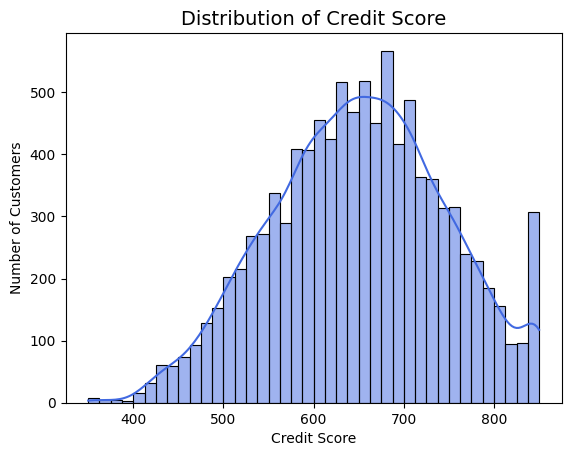

In [29]:
sns.histplot(df['CreditScore'], kde=True, bins=40, color='royalblue')

plt.title('Distribution of Credit Score', fontsize=14)
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.show()

### Balance vs salary

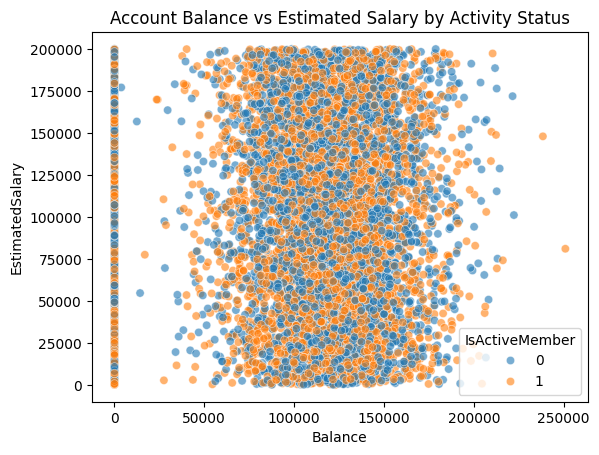

In [30]:
sns.scatterplot(data=df, x='Balance', y='EstimatedSalary', hue='IsActiveMember', alpha=0.6)
plt.title('Account Balance vs Estimated Salary by Activity Status')
plt.show()

### Credit score vs balance

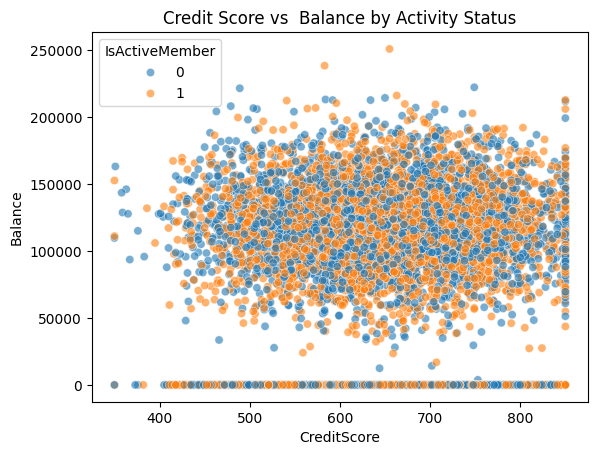

In [31]:
sns.scatterplot(data=df, x='CreditScore', y='Balance', hue='IsActiveMember', alpha=0.6)
plt.title('Credit Score vs  Balance by Activity Status')
plt.show()

### Key Insights:
1. Zero Balance Customers alongs to only two country spain and france.
2. No relationship between credit vs balance.
3. Most balance amount is holded by only 1 - products usage customers.

# Churn Analysis

### Churn by active membership

In [32]:
(
    df.groupby('IsActiveMember')['Exited']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

,Exited
IsActiveMember,
0,26.85
1,14.27


### Churn by credit score group

In [33]:
(
    df.groupby('CreditScoreGroup')['Exited']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

/tmp/ipykernel_707/241118475.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CreditScoreGroup')['Exited']


,Exited
CreditScoreGroup,
Poor,22.02
Very Good,20.59
Fair,20.56
Excellent,19.54
Good,18.62


### Churn by num of products

In [34]:
df.groupby('NumOfProducts')['Exited'].mean().mul(100)

,Exited
NumOfProducts,
1,27.71
2,7.58
3,82.71
4,100.00


### Key Insights:
1. Customers using four products show a 100% churn rate; however, this segment contains only 19 customers. Therefore, while the churn rate is alarming, the business impact is limited due to the small customer base. The one-product segment should remain the primary retention priority because it combines a much larger customer base with a high churn rate.
2. Inactive customers have high churn rate.
3. Credit score group shows that customers which have low credit score usually have more churn rate.

# Risk Analysis

In [40]:
high_balance_threshold = df['Balance'].quantile(0.75)

In [41]:
high_value_inactive = df[
    (df['Balance'] >= high_balance_threshold) &
    (df['IsActiveMember'] == 0)
]

In [48]:
print(f" Customers who have high balance and not active have {high_value_inactive['Exited'].mean()*100:.2f} % churn rate")

 Customers who have high balance and not active have 30.47 % churn rate


# Executive Summary: Customer Churn & Retention Analysis Key Insights
### High-Value Risk Cohorts:
Germany represents the highest-risk regional market, exhibiting the highest churn rate despite leading in both average account balance and average credit score. Similarly, new customers represent a volatile, high-value segment with elevated churn rates alongside high average balances and strong credit profiles.

### Demographic Vulnerability:
 The 51–60 age demographic represents a critical attrition point, showing the highest churn rate coupled with the highest average balance.

### Product Utilization Impact:

Primary Risk: Customers utilizing only one product hold the majority of the total balance amount and exhibit high churn. Due to the massive size of this cohort, it poses the highest financial risk to the business.

Statistical Outliers: While customers utilizing four products show a 100% churn rate, this segment comprises only 19 individuals. While statistically alarming, its immediate business impact is low compared to the one-product cohort.

Engagement & Credit Risk Factors: Inactive customers correlate heavily with high attrition. Additionally, credit score segmentation reveals an inverse relationship: lower credit score brackets demonstrate progressively higher churn rates.

Regional Balance Distribution: Zero-balance accounts are exclusively concentrated within France and Spain, where approximately 50% of the regional customer base maintains a balance of zero. Conversely, Germany has zero customers with a balance of zero.

# Strategic Recommendations
### Prioritize the German Market:
Launch targeted retention campaigns in Germany. Because this market has the highest average balances and zero zero-balance accounts, mitigating churn here yields the highest immediate return on investment (ROI).

### Optimize Onboarding for New High-Value Customers:
Introduce structured introductory benefits, personalized onboarding flows, or loyalty rewards for new customers to stabilize retention during their high-risk initial lifecycle phase.

### Execute a Product Cross-Selling Strategy:
Develop targeted cross-selling initiatives (e.g., moving single-product users to two products) to deepen customer engagement, secure the large volume of capital held by this group, and lower their propensity to churn.

### Investigate Mature Demographic Pain Points:
Conduct targeted qualitative research or customer care outreach for the 51–60 age bracket to identify and resolve specific service friction points causing high-balance attrition.

### Address Capital Inactivity in France & Spain:
Design regional financial products or high-yield incentive structures specifically for France and Spain to encourage zero-balance customers to deposit capital.

# Conclusion
To maximize customers, retention strategies must pivot toward high-value, high-risk segments. Immediate optimization efforts should focus on stabilizing new customers, driving cross-product adoption among single-product users, addressing service friction within the 51–60 age cohort, and deploying localized regional policies tailored to the unique balance structures of Germany, France, and Spain.


# Project Limitations

This dataset contains customer demographic and account information but does not include transaction history, revenue, or profitability metrics.
Therefore, analyses related to customer lifetime value, branch profitability, or transaction behaviour were outside the scope of this project.
Future work could incorporate transaction-level data to build more comprehensive customer value and retention models.